In [1]:
import sys
sys.path.append("..")

import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
PROC_DIR = Path("../data/processed")

d = joblib.load(PROC_DIR / "splits.joblib")
Xtr, Xte = d["Xtr"], d["Xte"]
y_train, y_test = d["y_train_p"], d["y_test_p"]

print("Classes:", sorted(y_train.unique()))
print(y_train.value_counts())

Classes: ['high', 'low', 'medium']
priority
medium    3939
high      3663
low       1918
Name: count, dtype: int64


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", C=2.0),
    "Linear SVM": LinearSVC(class_weight="balanced", C=2.0, max_iter=5000),
}

rows = []
for name, m in models.items():
    m.fit(Xtr, y_train)
    p = m.predict(Xte)
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, p),
                 "Macro-F1": f1_score(y_test, p, average="macro")})

res = pd.DataFrame(rows).sort_values("Macro-F1", ascending=False)
print(res.round(4).to_string(index=False))
print("\nBaseline (queue lookup): acc=0.531  macroF1=0.433")
print("Baseline (majority)    : acc=0.419")

              Model  Accuracy  Macro-F1
         Linear SVM    0.6014    0.5798
Logistic Regression    0.5863    0.5697
        Naive Bayes    0.5716    0.5167

Baseline (queue lookup): acc=0.531  macroF1=0.433
Baseline (majority)    : acc=0.419


In [3]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.2,
                    subsample=0.8, colsample_bytree=0.8,
                    tree_method="hist", n_jobs=-1, random_state=42)
xgb.fit(Xtr, le.fit_transform(y_train))

p = le.inverse_transform(xgb.predict(Xte))
print(f"XGBoost: acc={accuracy_score(y_test,p):.4f}  macroF1={f1_score(y_test,p,average='macro'):.4f}")

XGBoost: acc=0.5531  macroF1=0.4976


In [4]:
for C in [0.5, 1.0, 2.0, 4.0, 8.0]:
    m = LinearSVC(class_weight="balanced", C=C, max_iter=5000).fit(Xtr, y_train)
    p = m.predict(Xte)
    print(f"C={C:<5} acc={accuracy_score(y_test,p):.4f}  macroF1={f1_score(y_test,p,average='macro'):.4f}")

C=0.5   acc=0.5901  macroF1=0.5678
C=1.0   acc=0.6006  macroF1=0.5803
C=2.0   acc=0.6014  macroF1=0.5798
C=4.0   acc=0.5985  macroF1=0.5774
C=8.0   acc=0.5930  macroF1=0.5718


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv(PROC_DIR / "tickets_clean_en.csv")

# rebuild the exact same split
from sklearn.model_selection import train_test_split
tr, te = train_test_split(df, test_size=0.2, random_state=42, stratify=df["queue"])

vec_nostop = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                             min_df=3, max_df=0.85, sublinear_tf=True,
                             stop_words=None)
Xtr2 = vec_nostop.fit_transform(tr["text"])
Xte2 = vec_nostop.transform(te["text"])

m = LinearSVC(class_weight="balanced", C=2.0, max_iter=5000).fit(Xtr2, tr["priority"])
p = m.predict(Xte2)
print(f"WITHOUT stop-word removal: acc={accuracy_score(te['priority'],p):.4f}  "
      f"macroF1={f1_score(te['priority'],p,average='macro'):.4f}")
print("WITH stop-word removal   : see 6.4 results")

WITHOUT stop-word removal: acc=0.6098  macroF1=0.5932
WITH stop-word removal   : see 6.4 results


In [6]:
print("Split check — should be identical:")
print(len(tr), len(te), (te["priority"].values == y_test.values).all())

Split check — should be identical:
9520 2381 True


              precision    recall  f1-score   support

        high       0.64      0.63      0.63       906
         low       0.50      0.46      0.48       478
      medium       0.61      0.64      0.63       997

    accuracy                           0.60      2381
   macro avg       0.58      0.58      0.58      2381
weighted avg       0.60      0.60      0.60      2381



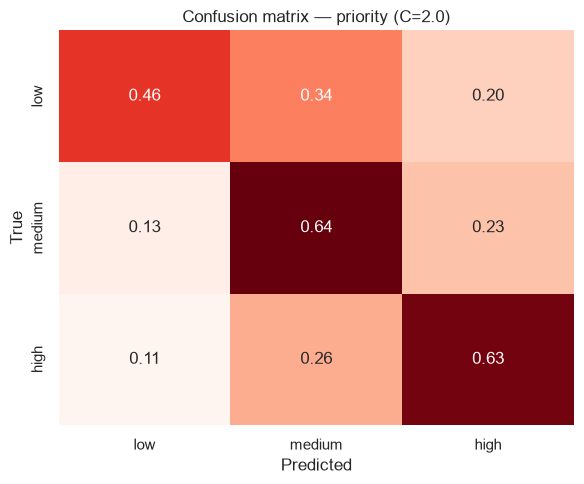

In [7]:
BEST_C = 2.0

final_p = LinearSVC(class_weight="balanced", C=BEST_C, max_iter=5000).fit(Xtr, y_train)
pred = final_p.predict(Xte)

print(classification_report(y_test, pred, zero_division=0))

labels = ["low", "medium", "high"]
cm = confusion_matrix(y_test, pred, labels=labels, normalize="true")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion matrix — priority (C={BEST_C})")
plt.tight_layout(); plt.show()

In [8]:
feats = np.array(vec_nostop.get_feature_names_out()) if False else None
vec = joblib.load("../models/tfidf_vectorizer.joblib")
feats = np.array(vec.get_feature_names_out())

for i, cls in enumerate(final_p.classes_):
    top = feats[np.argsort(final_p.coef_[i])[-10:]][::-1]
    print(f"{cls:8s} -> {', '.join(top)}")

high     -> issue digital, loss, access event, appreciated look, dashboards, protocols ensure, crashed, request medical, restarting router, attempts medical
low      -> details api, issue require, terraform, guidance protecting, analytics financial, access vulnerability, new product, configuration errors, support require, systems unauthorized
medium   -> enhanced encryption, synchronization process, microsoft azure, practices ensure, scalability options, resource, hub, guidance recommendations, cache updating, unifi


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.read_csv(PROC_DIR / "tickets_clean_en.csv")
tr, te = train_test_split(df, test_size=0.2, random_state=42, stratify=df["queue"])

vectorizer = TfidfVectorizer(
    max_features=20000, ngram_range=(1,2),
    min_df=3, max_df=0.85, sublinear_tf=True,
    stop_words=None,
)
Xtr2 = vectorizer.fit_transform(tr["text"])
Xte2 = vectorizer.transform(te["text"])
print("Vocabulary:", len(vectorizer.vocabulary_))

Vocabulary: 20000


In [10]:
for C in [0.5, 1.0, 2.0, 4.0]:
    m = LinearSVC(class_weight="balanced", C=C, max_iter=5000).fit(Xtr2, tr["priority"])
    p = m.predict(Xte2)
    print(f"C={C:<5} acc={accuracy_score(te['priority'],p):.4f}  "
          f"macroF1={f1_score(te['priority'],p,average='macro'):.4f}")

C=0.5   acc=0.5930  macroF1=0.5710
C=1.0   acc=0.5976  macroF1=0.5758
C=2.0   acc=0.6098  macroF1=0.5932
C=4.0   acc=0.6144  macroF1=0.5973


In [11]:
for C in [1.0, 2.0, 4.0]:
    m = LinearSVC(class_weight="balanced", C=C, max_iter=5000).fit(Xtr2, tr["queue"])
    p = m.predict(Xte2)
    print(f"QUEUE C={C:<5} acc={accuracy_score(te['queue'],p):.4f}  "
          f"macroF1={f1_score(te['queue'],p,average='macro'):.4f}   (was 0.5371)")

QUEUE C=1.0   acc=0.5397  macroF1=0.5227   (was 0.5371)
QUEUE C=2.0   acc=0.5456  macroF1=0.5327   (was 0.5371)
QUEUE C=4.0   acc=0.5489  macroF1=0.5336   (was 0.5371)


In [12]:
print("=== PRIORITY ===")
for C in [4.0, 8.0, 16.0, 32.0]:
    m = LinearSVC(class_weight="balanced", C=C, max_iter=10000).fit(Xtr2, tr["priority"])
    p = m.predict(Xte2)
    print(f"C={C:<6} acc={accuracy_score(te['priority'],p):.4f}  "
          f"macroF1={f1_score(te['priority'],p,average='macro'):.4f}")

print("\n=== QUEUE ===")
for C in [4.0, 8.0, 16.0, 32.0]:
    m = LinearSVC(class_weight="balanced", C=C, max_iter=10000).fit(Xtr2, tr["queue"])
    p = m.predict(Xte2)
    print(f"C={C:<6} acc={accuracy_score(te['queue'],p):.4f}  "
          f"macroF1={f1_score(te['queue'],p,average='macro'):.4f}")

=== PRIORITY ===
C=4.0    acc=0.6144  macroF1=0.5973
C=8.0    acc=0.6086  macroF1=0.5906
C=16.0   acc=0.6031  macroF1=0.5847
C=32.0   acc=0.6006  macroF1=0.5809

=== QUEUE ===
C=4.0    acc=0.5489  macroF1=0.5336
C=8.0    acc=0.5460  macroF1=0.5339
C=16.0   acc=0.5464  macroF1=0.5339
C=32.0   acc=0.5430  macroF1=0.5312


In [13]:
import joblib

C_QUEUE    = 4.0
C_PRIORITY = 4.0

# 1. the shared vectorizer (overwrites the stop-word version)
joblib.dump(vectorizer, "../models/tfidf_vectorizer.joblib")

# 2. refresh the splits file so later notebooks load the right matrices
joblib.dump(
    {"Xtr": Xtr2, "Xte": Xte2,
     "y_train_q": tr["queue"],    "y_test_q": te["queue"],
     "y_train_p": tr["priority"], "y_test_p": te["priority"]},
    PROC_DIR / "splits.joblib",
)
print("Vectorizer and splits updated.")

Vectorizer and splits updated.


In [14]:
from sklearn.calibration import CalibratedClassifierCV

queue_clf = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", C=C_QUEUE, max_iter=10000),
    method="sigmoid", cv=5
).fit(Xtr2, tr["queue"])

prio_clf = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", C=C_PRIORITY, max_iter=10000),
    method="sigmoid", cv=5
).fit(Xtr2, tr["priority"])

for name, clf, y in [("QUEUE", queue_clf, te["queue"]),
                     ("PRIORITY", prio_clf, te["priority"])]:
    p = clf.predict(Xte2)
    print(f"{name:9s} acc={accuracy_score(y,p):.4f}  macroF1={f1_score(y,p,average='macro'):.4f}")

joblib.dump(queue_clf, "../models/queue_classifier.joblib")
joblib.dump(prio_clf,  "../models/priority_classifier.joblib")
print("\nModels exported.")

QUEUE     acc=0.5556  macroF1=0.5435
PRIORITY  acc=0.6018  macroF1=0.5473

Models exported.


In [15]:
from sklearn.metrics import confusion_matrix
labels = ["low", "medium", "high"]
cm = confusion_matrix(te["priority"], prio_clf.predict(Xte2), labels=labels, normalize="true")
print(f"Critical tickets correctly identified (high recall): {cm[2,2]:.3f}")
print(f"Critical tickets missed as low priority:             {cm[2,0]:.3f}")

Critical tickets correctly identified (high recall): 0.648
Critical tickets missed as low priority:             0.031


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

raw_p = LinearSVC(class_weight="balanced", C=4.0, max_iter=10000).fit(Xtr2, tr["priority"])
pred_raw = raw_p.predict(Xte2)

labels = ["low", "medium", "high"]
cm_raw = confusion_matrix(te["priority"], pred_raw, labels=labels, normalize="true")
print("RAW model:")
print(f"  high recall:        {cm_raw[2,2]:.3f}")
print(f"  high -> low errors: {cm_raw[2,0]:.3f}")
print("\nCALIBRATED: high recall 0.648, high -> low 0.031\n")
print(classification_report(te["priority"], pred_raw, zero_division=0))

RAW model:
  high recall:        0.637
  high -> low errors: 0.089

CALIBRATED: high recall 0.648, high -> low 0.031

              precision    recall  f1-score   support

        high       0.64      0.64      0.64       906
         low       0.53      0.50      0.51       478
      medium       0.63      0.65      0.64       997

    accuracy                           0.61      2381
   macro avg       0.60      0.60      0.60      2381
weighted avg       0.61      0.61      0.61      2381

